<a href="https://colab.research.google.com/github/nurfnick/Numerical_Methods/blob/master/Module_5_Interpolation/LagrangePoly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lagrange Interpolation and Runge's Phenomenon

This notebook demonstrates how to construct Lagrange interpolation polynomials and visualizes the 'blow-up' effect (known as **Runge's phenomenon**) that can happen when using a high degree polynomial with equally spaced points.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

def lagrange_builder(x_points, y_points):
    """
    Builds and returns a Lagrange interpolation polynomial function using scipy.
    """
    poly = lagrange(x_points, y_points)
    return poly

## Example 1: Runge's Phenomenon
Runge's phenomenon occurs when we try to interpolate the function:
$$f(x) = \frac{1}{1 + 25x^2}$$
over the interval $[-1, 1]$ using equally spaced points. As the number of points $N$ increases, the interpolation polynomial oscillates wildly near the ends of the interval.

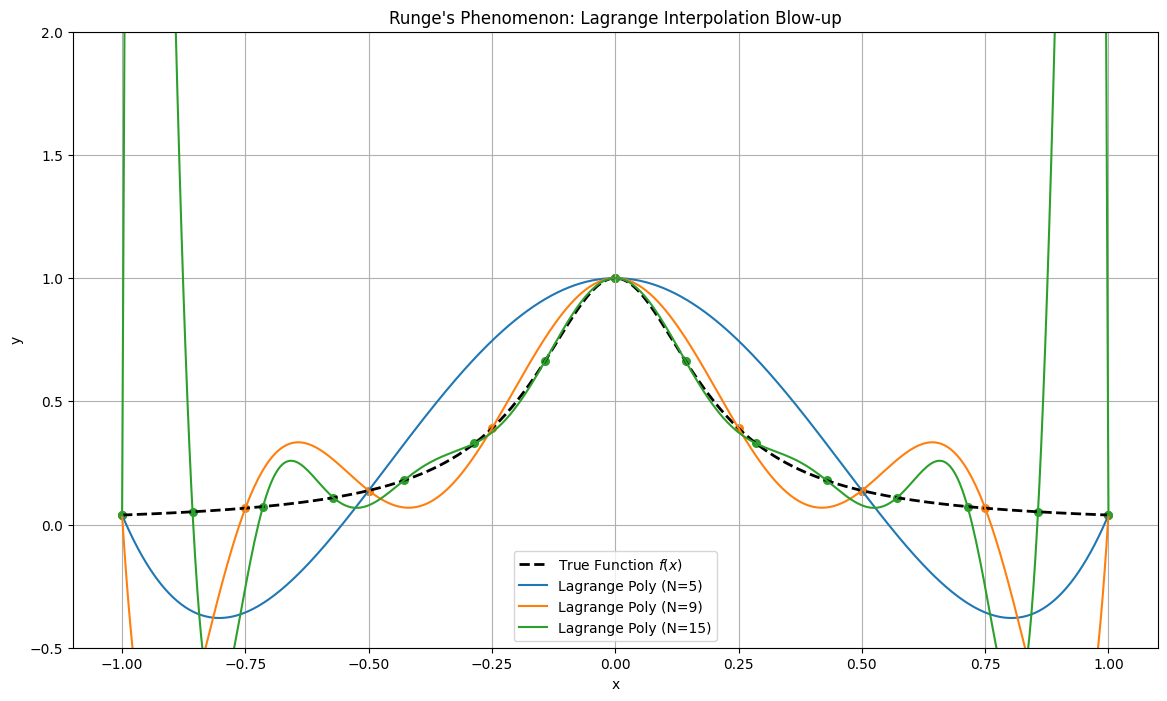

In [5]:
# Define the Runge function
def runge_func(x):
    return 1 / (1 + 25 * x**2)

# Dense x values for plotting the true function
x_dense = np.linspace(-1, 1, 500)
y_true = runge_func(x_dense)

# Plotting configurations for different number of interpolation points
num_points_list = [5, 9, 15]

plt.figure(figsize=(14, 8))
plt.plot(x_dense, y_true, 'k--', label='True Function $f(x)$', linewidth=2)

for n in num_points_list:
    # Generate equally spaced sample points
    x_nodes = np.linspace(-1, 1, n)
    y_nodes = runge_func(x_nodes)

    # Build Lagrange polynomial
    poly = lagrange_builder(x_nodes, y_nodes)
    y_interp = poly(x_dense)

    plt.plot(x_dense, y_interp, label=f'Lagrange Poly (N={n})')
    plt.scatter(x_nodes, y_nodes, s=30)

plt.title("Runge's Phenomenon: Lagrange Interpolation Blow-up")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-0.5, 2.0)
plt.legend()
plt.grid(True)
plt.show()

## Example 2: Mitigation using Chebyshev Nodes
To prevent this edge blow-up, we can transition from equally spaced nodes to **Chebyshev nodes**, which cluster points near the boundaries of the interval $[-1, 1]$.

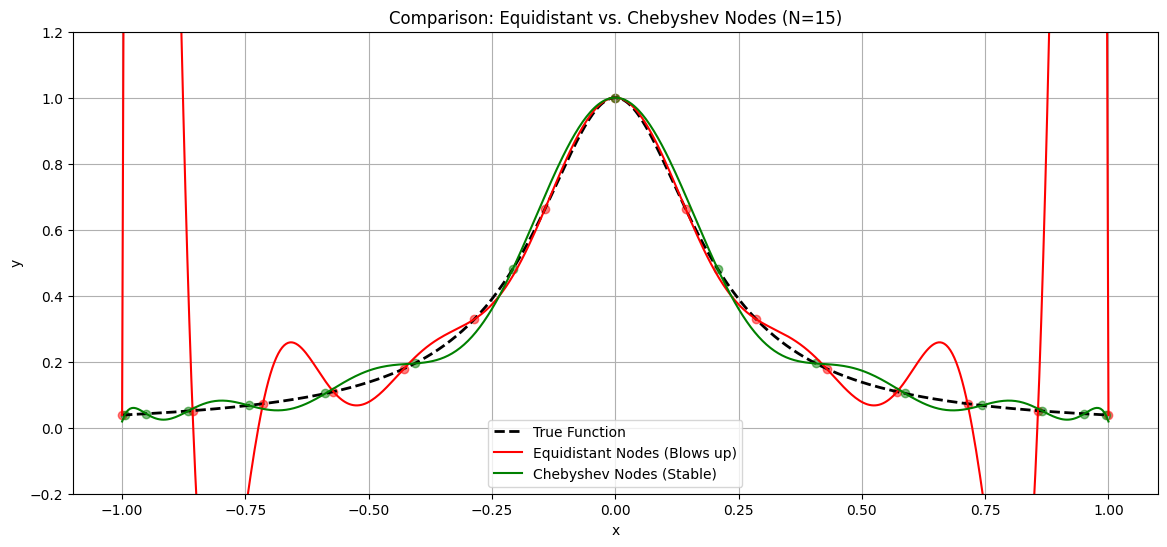

In [6]:
# Let's compare N=15 equally spaced points vs N=15 Chebyshev nodes
n_nodes = 15

# Equally spaced
x_equal = np.linspace(-1, 1, n_nodes)
y_equal = runge_func(x_equal)
poly_equal = lagrange_builder(x_equal, y_equal)

# Chebyshev spaced
i = np.arange(1, n_nodes + 1)
x_cheb = np.cos((2 * i - 1) * np.pi / (2 * n_nodes))
y_cheb = runge_func(x_cheb)
poly_cheb = lagrange_builder(x_cheb, y_cheb)

plt.figure(figsize=(14, 6))
plt.plot(x_dense, y_true, 'k--', label='True Function', linewidth=2)
plt.plot(x_dense, poly_equal(x_dense), 'r', label='Equidistant Nodes (Blows up)')
plt.plot(x_dense, poly_cheb(x_dense), 'g', label='Chebyshev Nodes (Stable)')
plt.scatter(x_equal, y_equal, color='red', alpha=0.5)
plt.scatter(x_cheb, y_cheb, color='green', alpha=0.5)

plt.title("Comparison: Equidistant vs. Chebyshev Nodes (N=15)")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True)
plt.show()